In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_regression

In [20]:
df = pd.read_csv("switch_stats.csv")
df.columns = [
    "rel_pile_change",
    "rounds_since_switch"
]
df

,rel_pile_change,rounds_since_switch
0,15.25,0
1,21.75,1
2,2.00,0
3,-1.00,0
4,2.00,3
...,...,...
6508,1.00,3
6509,1.00,4
6510,6.50,5
6511,3.50,0


In [21]:
df.describe()

,rel_pile_change,rounds_since_switch
count,6513.000000,6513.000000
mean,0.138032,5.073085
std,3.347627,5.996943
min,-49.000000,0.000000
25%,-1.000000,1.000000
50%,1.000000,3.000000
75%,1.000000,7.000000
max,50.000000,53.000000


In [22]:
# Remove rows where rel_pile_change is more than X standard deviations from the mean
df = df[
    np.abs(df["rel_pile_change"] - df["rel_pile_change"].mean())
    <= (3 * df["rel_pile_change"].std())
]
df

,rel_pile_change,rounds_since_switch
2,2.0,0
3,-1.0,0
4,2.0,3
5,1.0,0
6,-1.0,3
...,...,...
6507,2.5,2
6508,1.0,3
6509,1.0,4
6510,6.5,5


In [23]:
df.describe()

,rel_pile_change,rounds_since_switch
count,6385.000000,6385.000000
mean,0.170439,5.125450
std,2.106080,6.023613
min,-9.750000,0.000000
25%,-1.000000,1.000000
50%,1.000000,3.000000
75%,1.000000,7.000000
max,10.000000,53.000000


Coef: [0.00979759]
P-value: 0.0007852400773813439


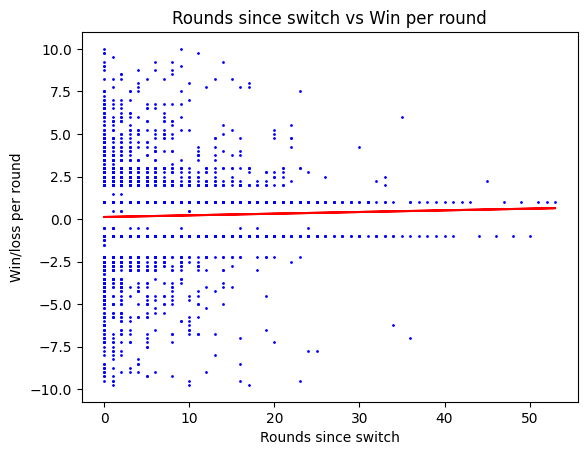

In [24]:
# Plot randomness vs win per round
plt.scatter(df["rounds_since_switch"], df["rel_pile_change"], c="blue", s=1)
model = LinearRegression().fit(df[["rounds_since_switch"]], df["rel_pile_change"])
print("Coef:", model.coef_)
print("P-value:", model.score(df[["rounds_since_switch"]], df["rel_pile_change"]))
plt.plot(df["rounds_since_switch"], model.predict(df[["rounds_since_switch"]]), color="red")
plt.xlabel("Rounds since switch")
plt.ylabel("Win/loss per round")
plt.title("Rounds since switch vs Win per round")
plt.show()